In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO NORMANDIE REGION
print("\n🎯 FILTERING TO NORMANDIE REGION")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Filter to Normandie
df_quotes_normandie = df_quotes[df_quotes['nom_region'] == 'Normandie'].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Normandie customers: {df_quotes_normandie['numero_compte'].nunique():,}")
print(f"Quotes: {len(df_quotes_normandie):,}")

# Save to file
df_quotes_normandie.to_csv('cleaned_quote_data_normandie.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_normandie.csv")


🎯 FILTERING TO NORMANDIE REGION
Original customers: 23,888
Normandie customers: 10,558
Quotes: 15,229

✅ Saved to cleaned_quote_data_normandie.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_normandie.csv')

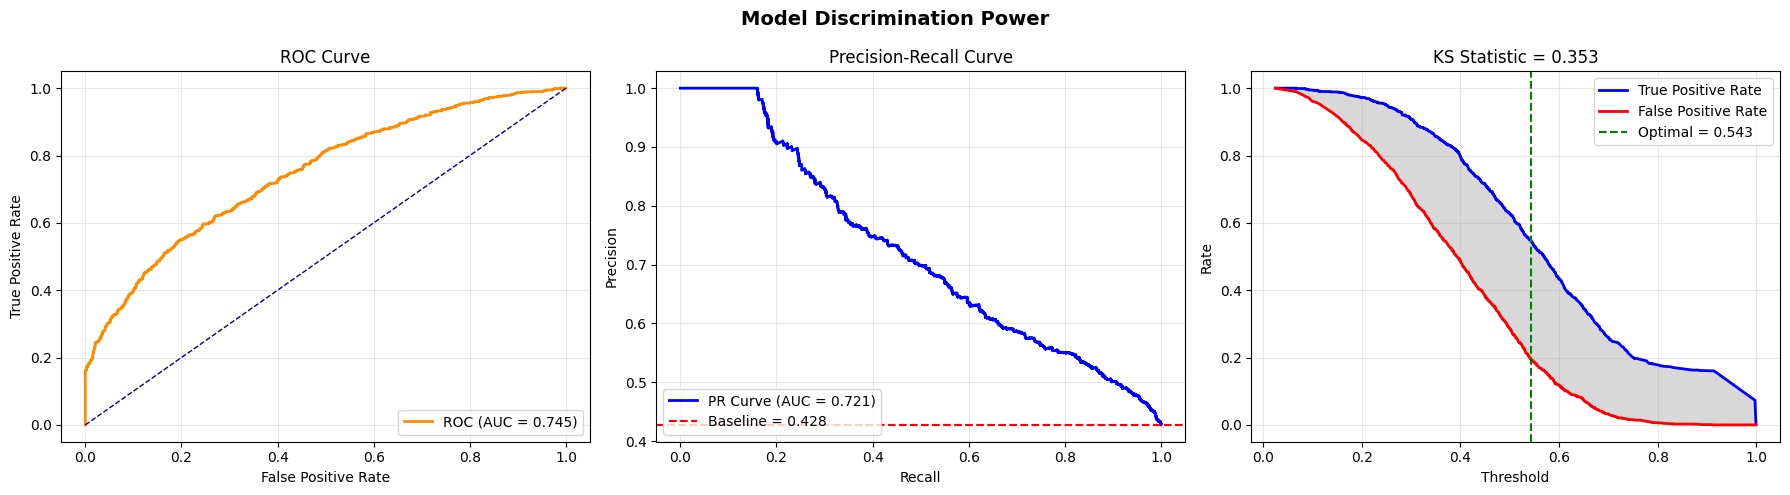

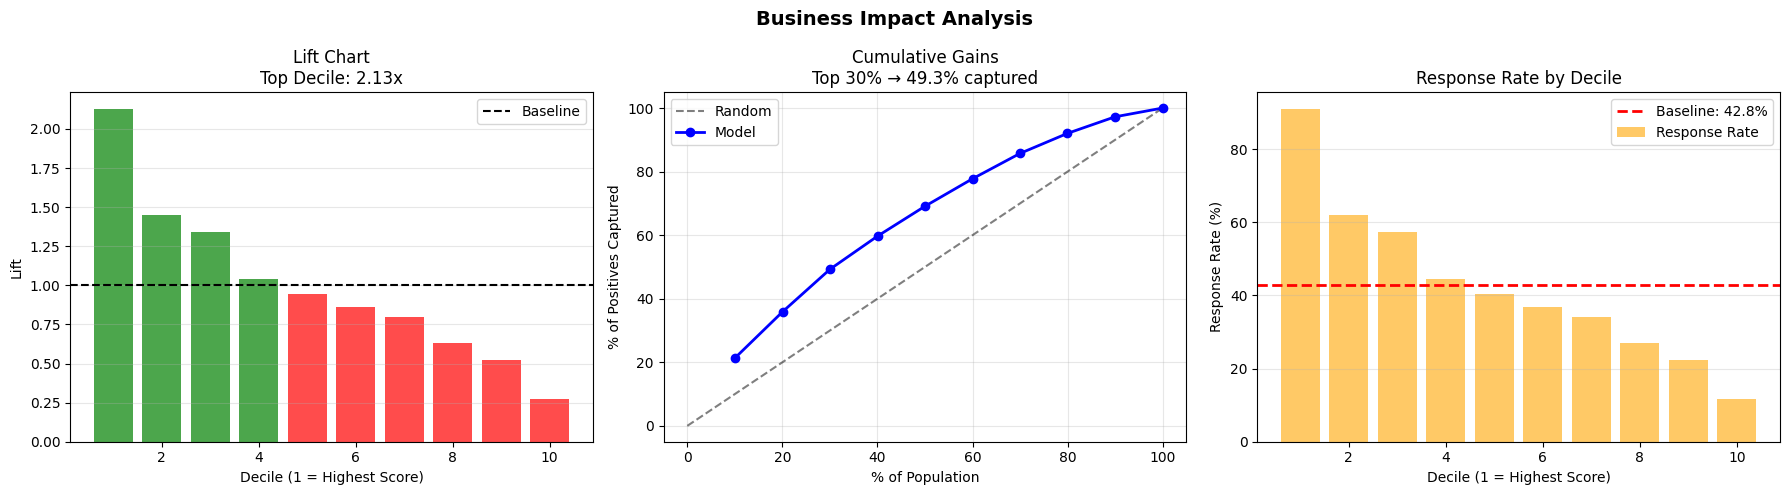

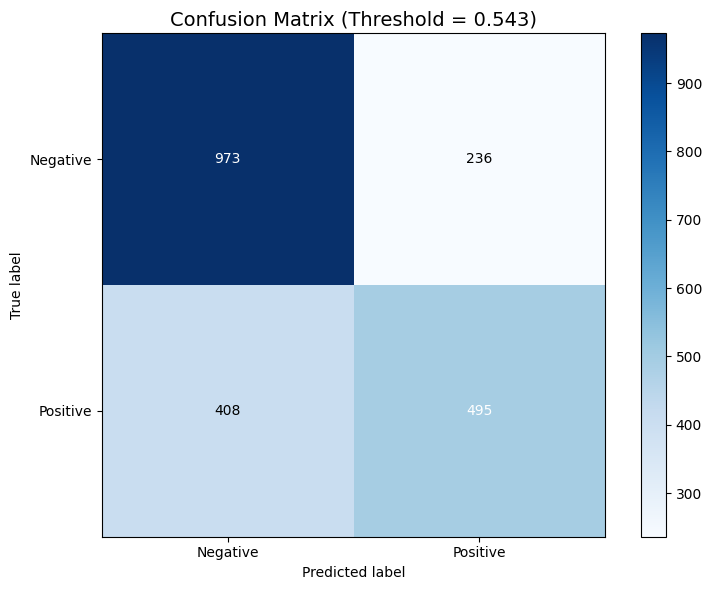


🔍 COMPREHENSIVE ERROR ANALYSIS
COMPREHENSIVE ERROR ANALYSIS

📊 1. BASIC ERROR METRICS
------------------------------------------------------------
Confusion Matrix:
  True Negatives:     865 (Correctly rejected)
  False Positives:    344 (Predicted YES, actual NO) ← WASTED EFFORT
  False Negatives:    336 (Predicted NO, actual YES) ← MISSED OPPORTUNITIES
  True Positives:     567 (Correctly predicted)

Error Analysis:
  • Total errors: 680 (32.2% of predictions)
  • False Positive rate: 16.3% (wasted sales effort)
  • False Negative rate: 15.9% (missed conversions)

📈 2. PREDICTION CONFIDENCE ANALYSIS
------------------------------------------------------------
Accuracy by Confidence Level:
  • Very Low   confidence: 82.2% accurate (467 predictions)
  • Low        confidence: 70.4% accurate (335 predictions)
  • Medium     confidence: 54.2% accurate (775 predictions)
  • High       confidence: 59.8% accurate (264 predictions)
  • Very High  confidence: 86.3% accurate (271 predictions)

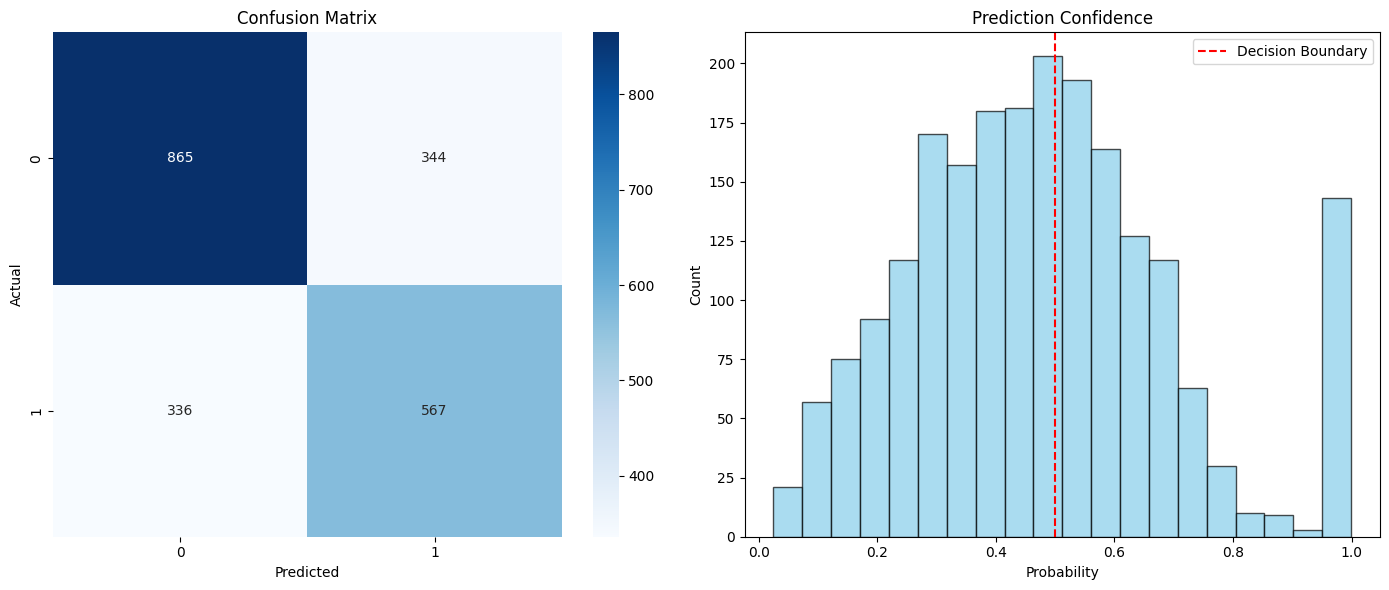

In [4]:
with redirect_stdout(open('/dev/null', 'w')):
    result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])